In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully ✅")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully ✅


In [2]:
# Load the dataset
df = pd.read_csv('c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv')

# First look at the data
print("Shape of dataset (rows, columns):", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Shape of dataset (rows, columns): (572, 5)

First 5 rows:
       TV      Radio  Social Media Influencer       Sales
0     Low   3.518070      2.293790      Micro   55.261284
1     Low   7.756876      2.572287       Mega   67.574904
2    High  20.348988      1.227180      Micro  272.250108
3  Medium  20.108487      2.728374       Mega  195.102176
4    High  31.653200      7.776978       Nano  273.960377

Column names: ['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']

Missing values:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

Basic statistics:
            Radio  Social Media       Sales
count  572.000000    572.000000  572.000000
mean    17.520616      3.333803  189.296908
std      9.290933      2.238378   89.871581
min      0.109106      0.000031   33.509810
25%     10.699556      1.585549  118.718722
50%     17.149517      3.150111  184.005362
75%     24.606396      4.730408  264.500118
max     42.271579     11.403625  

Unique values in TV column: <StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str

Unique values in Influencer column: <StringArray>
['Micro', 'Mega', 'Nano', 'Macro']
Length: 4, dtype: str


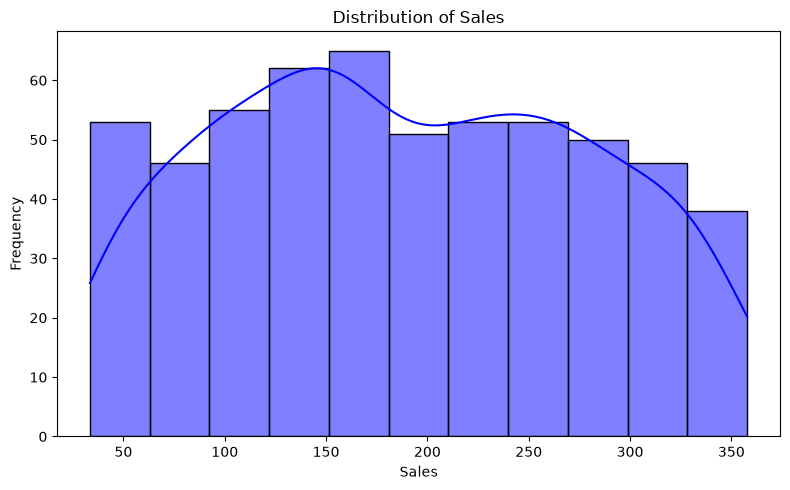

In [3]:
# Check how many unique values are in TV and Influencer columns
print("Unique values in TV column:", df['TV'].unique())
print("\nUnique values in Influencer column:", df['Influencer'].unique())

# Check the distribution of Sales
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], kde=True, color='blue')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [4]:
# Convert TV column (Low/Medium/High) into numbers
tv_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['TV'] = df['TV'].map(tv_mapping)

# Convert Influencer column (Nano/Micro/Mega) into numbers
influencer_mapping = {'Nano': 1, 'Micro': 2, 'Mega': 3}
df['Influencer'] = df['Influencer'].map(influencer_mapping)

# Confirm the conversion worked
print("First 5 rows after conversion:")
print(df.head())
print("\nBasic statistics after conversion:")
print(df.describe())

First 5 rows after conversion:
   TV      Radio  Social Media  Influencer       Sales
0   1   3.518070      2.293790         2.0   55.261284
1   1   7.756876      2.572287         3.0   67.574904
2   3  20.348988      1.227180         2.0  272.250108
3   2  20.108487      2.728374         3.0  195.102176
4   3  31.653200      7.776978         1.0  273.960377

Basic statistics after conversion:
               TV       Radio  Social Media  Influencer       Sales
count  572.000000  572.000000    572.000000  445.000000  572.000000
mean     1.938811   17.520616      3.333803    1.955056  189.296908
std      0.799363    9.290933      2.238378    0.812489   89.871581
min      1.000000    0.109106      0.000031    1.000000   33.509810
25%      1.000000   10.699556      1.585549    1.000000  118.718722
50%      2.000000   17.149517      3.150111    2.000000  184.005362
75%      3.000000   24.606396      4.730408    3.000000  264.500118
max      3.000000   42.271579     11.403625    3.000000  35

In [5]:
# Check how many missing values we now have
print("Missing values in each column:")
print(df.isnull().sum())

# Fill missing Influencer values with the most common value
df['Influencer'] = df['Influencer'].fillna(df['Influencer'].mode()[0])

# Confirm it's fixed
print("\nMissing values after fix:")
print(df.isnull().sum())

print("\nInfluencer column count after fix:", df['Influencer'].count())

Missing values in each column:
TV                0
Radio             0
Social Media      0
Influencer      127
Sales             0
dtype: int64

Missing values after fix:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

Influencer column count after fix: 572


Correlation Matrix:
                    TV     Radio  Social Media  Influencer
TV            1.000000  0.803377      0.511758    0.010711
Radio         0.803377  1.000000      0.629941    0.038155
Social Media  0.511758  0.629941      1.000000    0.040805
Influencer    0.010711  0.038155      0.040805    1.000000


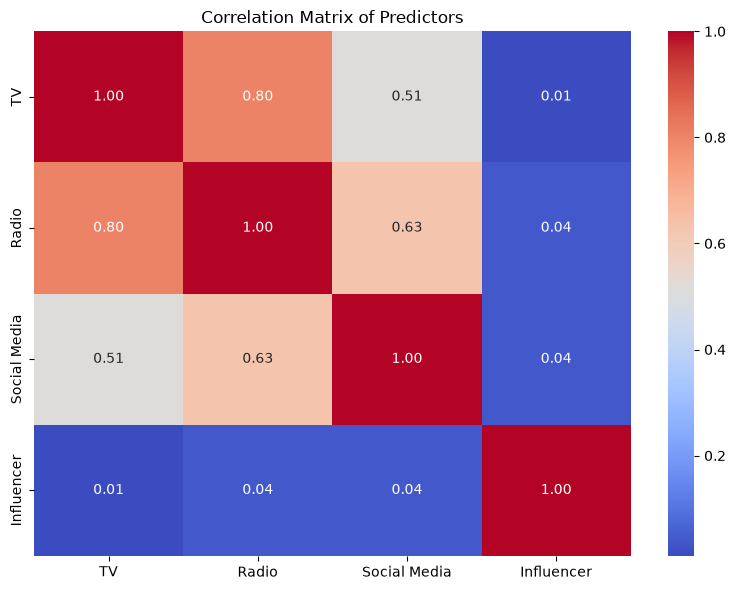

In [6]:
# Select only the independent variables (predictors)
X_vars = df[['TV', 'Radio', 'Social Media', 'Influencer']]

# Calculate correlation matrix
corr_matrix = X_vars.corr()
print("Correlation Matrix:")
print(corr_matrix)

# Draw the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Predictors')
plt.tight_layout()
plt.show()

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare the data with a constant column
X_vif = X_vars.copy()
X_vif['const'] = 1

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vars.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(len(X_vars.columns))]

print("VIF Results:")
print(vif_data)
print("\nReminder:")
print("VIF < 5 = Good ✅")
print("VIF 5-10 = Moderate concern ⚠️")
print("VIF > 10 = Serious problem ❌")

VIF Results:
        Feature       VIF
0            TV  2.823845
1         Radio  3.455939
2  Social Media  1.658949
3    Influencer  1.003071

Reminder:
VIF < 5 = Good ✅
VIF 5-10 = Moderate concern ⚠️
VIF > 10 = Serious problem ❌


In [8]:
import statsmodels.api as sm

# Define X (predictors) and y (target)
X = df[['TV', 'Radio', 'Social Media', 'Influencer']]
y = df['Sales']

# Add a constant (intercept) - statsmodels requires this
X = sm.add_constant(X)

# Build and fit the model
model = sm.OLS(y, X).fit()

# Print the full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1336.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          6.57e-287
Time:                        08:31:17   Log-Likelihood:                -2713.8
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5459.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -14.4406      3.955     -3.651   

In [9]:
# Rebuild model with only significant variables (TV and Radio)
X2 = df[['TV', 'Radio']]
y = df['Sales']

# Add constant
X2 = sm.add_constant(X2)

# Build and fit the new model
model2 = sm.OLS(y, X2).fit()

# Print the summary
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     2676.
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          3.70e-290
Time:                        08:32:13   Log-Likelihood:                -2714.3
No. Observations:                 572   AIC:                             5435.
Df Residuals:                     569   BIC:                             5448.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.3902      3.066     -4.041      0.0

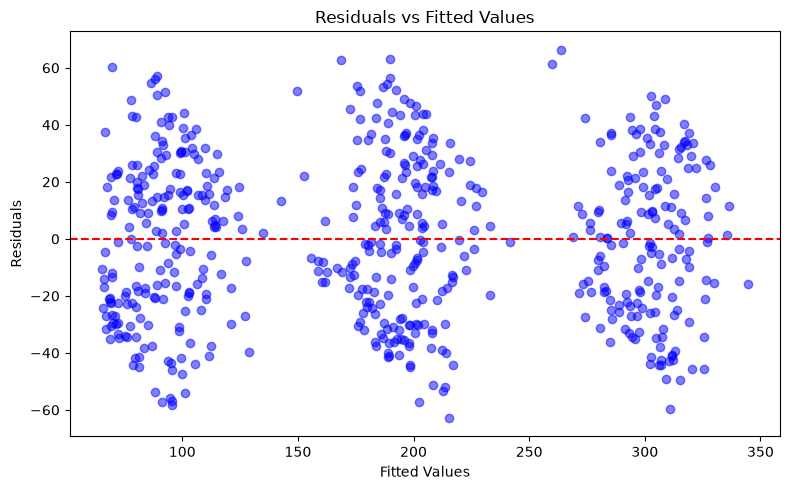

In [10]:
# Get fitted values and residuals
fitted_vals = model2.fittedvalues
residuals = model2.resid

# Plot Residuals vs Fitted
plt.figure(figsize=(8, 5))
plt.scatter(fitted_vals, residuals, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.tight_layout()
plt.show()

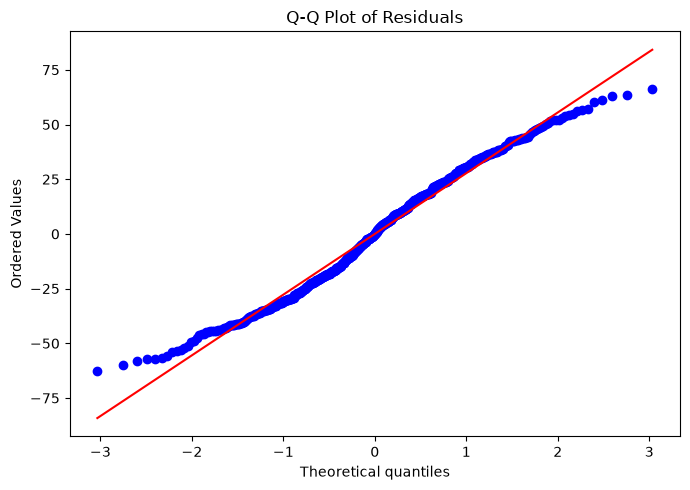

In [11]:
import scipy.stats as stats

# Q-Q Plot
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

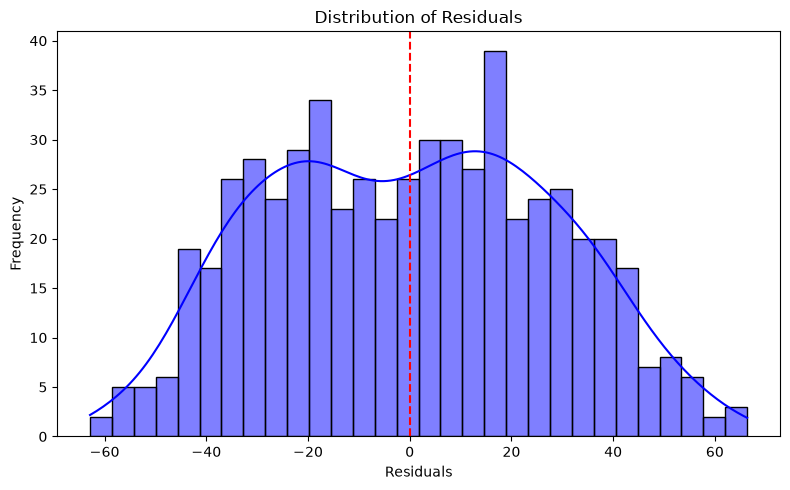

In [12]:
# Histogram of Residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Business Recommendation

### Model Performance
Our Multiple Linear Regression model explains **90.4%** of the variation 
in Sales (Adjusted R-squared = 0.904), which is an excellent fit.

### Significant Predictors
After testing all four variables, only **TV** and **Radio** were found to 
significantly predict Sales:
- **TV**: Moving up one spending level (e.g. Low to Medium) is associated 
with a **$77.32 increase** in Sales
- **Radio**: Each additional $1K spent on Radio is associated with a 
**$2.96 increase** in Sales

### Non-Significant Predictors
- **Social Media** (p-value = 0.800) — No significant effect on Sales
- **Influencer** (p-value = 0.382) — No significant effect on Sales

### Multicollinearity Check
All VIF values were below 5, confirming no serious multicollinearity 
among predictors.

### Model Assumption Checks
- ✅ Linearity — Satisfied
- ⚠️ Normality — Mild violation at tails, acceptable for real world data
- ⚠️ Homoscedasticity — Mild violation, model less precise at higher Sales values

### Final Recommendation
Based on our analysis, we recommend the marketing budget be **prioritised 
towards TV advertising**, as it has by far the strongest effect on Sales. 
**Radio** should be the second priority. **Social Media and Influencer** 
spending showed no statistically significant effect on Sales and should be 
reconsidered or investigated further before further investment.

# Marketing Budget Regression Analysis

## Dataset Description
The dataset contains 572 observations with the following columns:
- **TV**: TV advertising spend level (Low, Medium, High)
- **Radio**: Radio advertising spend in $thousands
- **Social Media**: Social media advertising spend in $thousands
- **Influencer**: Influencer type (Nano, Micro, Mega)
- **Sales**: Product sales figures

## Analysis Goals
- Check for multicollinearity among predictors using correlation matrix and VIF
- Build a Multiple Linear Regression model to predict Sales
- Validate model assumptions using diagnostic plots
- Deliver a business recommendation for marketing budget allocation

## Key Findings
- TV and Radio are the only statistically significant predictors of Sales
- The model explains 90.4% of variation in Sales (Adjusted R-squared = 0.904)
- Social Media and Influencer spend showed no significant effect on Sales
- All VIF values were below 5 confirming no multicollinearity issues

## Environment Setup
Run this command to install all required libraries:
pip install pandas seaborn statsmodels scipy matplotlib numpy

## Files
- `multiple_regression_analysis.ipynb` — Main analysis notebook
- `c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv` — Dataset